In [25]:
# ----- Phase 0: Imports & Setup -----
#pip install sqlalchemy, pandas, psycopg2, psycopg2-binary
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from pulp import LpProblem, LpVariable, LpMaximize, LpInteger
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os

In [26]:
#Phase 1: Database Connection Setup
def connect_to_database():
    conn_params = {
    "host" : "ttc-data-traffic-data.b.aivencloud.com",
    "database" : "defaultdb",
    "user" : "group4ttc",
    "password" : "Gr0up$004",
    "port" : "25159"
    }
    engine = create_engine(f"postgresql+psycopg2://{conn_params['user']}:{conn_params['password']}@{conn_params['host']}:{conn_params['port']}/{conn_params['database']}?sslmode=require")
    return engine

def read_table(table_name):
    cxn = connect_to_database()
    query = f'SELECT * FROM gold."gold.{table_name}";'
    df = pd.read_sql_query(query, cxn)
    return df

In [27]:
# Main execution (all code to be run inside "if __name__ == '__main__':" statement)
if __name__ == "__main__":
    # ----- Phase 2: Riders regression analysis and cost regression analysis -----
    # Riders regression Analysis (check linearity for decision variables coefficients):
    # Read fact_transit table
    transit_df = read_table("fact_transit")
    route_df = read_table("dim_route")
    print(transit_df.columns)
    print(route_df.columns)

    reg_X = transit_df[['trips_per_day', 'hours_per_day']]
    reg_y = transit_df['riders_per_day']

    reg_model = LinearRegression()
    reg_model.fit(reg_X, reg_y)

    x, y = reg_model.coef_
    intercept = reg_model.intercept_

    print("\nRegression Coefficients:")
    print(f"x (Trips): {x:.2f}, y (Hours): {y:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R² Score: {reg_model.score(reg_X, reg_y):.4f}")

Index(['riders_per_day', 'hours_per_day', 'kilometres_per_day',
       'vehicle_am_peak', 'vehicle_pm_peak', 'route_id', 'trip_id',
       'trip_stop_sequence_id', 'trips_per_day', 'riders_per_hour',
       'riders_per_trip', 'operational_cost_per_rider',
       'operational_cost_per_day', 'trip_duration', 'route_duration',
       'load_factor_per_trip', 'service_span', 'trips_on_peak',
       'trips_off_peak', 'off_peak_trip_ratio'],
      dtype='object')
Index(['route_id', 'route_name', 'route_long_name', 'route_type', 'bus_type',
       'bus_capacity'],
      dtype='object')

Regression Coefficients:
x (Trips): 13.50, y (Hours): 41.41
Intercept: -939.71
R² Score: 0.9466


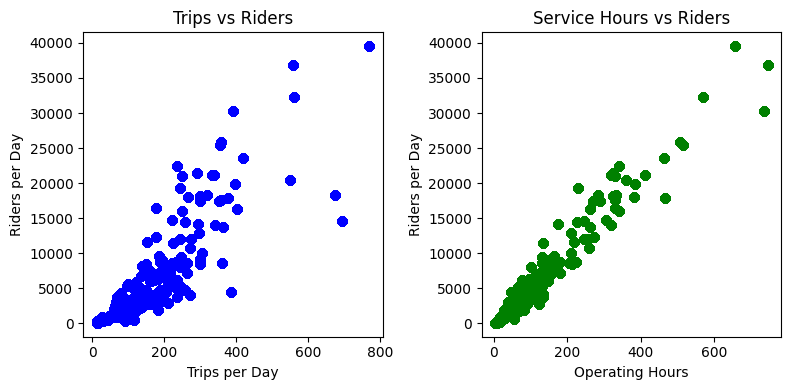

In [28]:
    # ----- Visualize Linear Relationships -----
    plt.figure(figsize=(12, 4))

    # Trips vs Riders
    plt.subplot(1, 3, 1)
    plt.scatter(transit_df['trips_per_day'], transit_df['riders_per_day'], color='blue')
    plt.title('Trips vs Riders')
    plt.xlabel('Trips per Day')
    plt.ylabel('Riders per Day')

    # Service Hours vs Riders
    plt.subplot(1, 3, 2)
    plt.scatter(transit_df['hours_per_day'], transit_df['riders_per_day'], color='green')
    plt.title('Service Hours vs Riders')
    plt.xlabel('Operating Hours')
    plt.ylabel('Riders per Day')


    plt.tight_layout()
    plt.show()

In [29]:
    # Cost Regression Analysis (find marginal costs)
    # Prepare features and target
    X_cost = transit_df[['trips_per_day', 'hours_per_day']]
    y_cost = transit_df['operational_cost_per_day']

    #Fit linear regression model
    cost_model = LinearRegression()
    cost_model.fit(X_cost, y_cost)

    # Extract results
    cost_per_trip, cost_per_hour = cost_model.coef_
    intercept_cost = cost_model.intercept_
    r2_cost = cost_model.score(X_cost, y_cost)

    print("\n=== COST REGRESSION RESULTS ===")
    print(f"Intercept: {intercept_cost:.2f}")
    print(f"Cost per Trip (relative importance): {cost_per_trip:.4f}")
    print(f"Cost per Service Hour (relative importance): {cost_per_hour:.4f}")
    print(f"R² Score: {r2_cost:.4f}")


=== COST REGRESSION RESULTS ===
Intercept: 0.00
Cost per Trip (relative importance): -0.0000
Cost per Service Hour (relative importance): 275.0000
R² Score: 1.0000


In [ ]:
    # ----- Phase 3: Create Dataframe for inputted routes -----
    # Ask user to input one or more route IDs (comma-separated)
    user_input = input("\nEnter route_id(s) to optimize (comma-separated): ").strip()

    # Parse and strip input
    found = [r.strip() for r in user_input.split(",") if r.strip()]

    # Normalize types
    # If route_id column is numeric, convert found to numeric
    if pd.api.types.is_numeric_dtype(transit_df['route_id']):
        found = [int(r) if r.isdigit() else r for r in found]
    else:
        # Otherwise make sure both are strings
        transit_df['route_id'] = transit_df['route_id'].astype(str)
        found = [str(r) for r in found]

    # Validate input
    missing_routes = [r for r in found if r not in transit_df['route_id'].values]
    if missing_routes:
        raise ValueError(f"Error: The following route_id(s) not found in transit_df: {missing_routes}")

    print(f"\nRoutes selected for optimization: {found}")

    #Note: Target routes used - 74968,74833,74821,74803,74796


Routes selected for optimization: [74968, 74833, 74821, 74803, 74796]


In [31]:
    # Create dataset
    before_per_day = (
        transit_df[transit_df['route_id'].isin(found)]
        [['route_id','riders_per_day', 'riders_per_hour', 'riders_per_trip',
        'operational_cost_per_rider','operational_cost_per_day',
        'trips_per_day', 'hours_per_day']]
        .drop_duplicates(subset='route_id', keep='first')
        .reset_index(drop=True)
    )

    # Convert KPIs to integer type
    before_per_day = before_per_day.assign(
        riders_per_day=lambda df: df['riders_per_day'].astype(int),
        riders_per_hour=lambda df: df['riders_per_hour'].astype(int),
        riders_per_trip=lambda df: df['riders_per_trip'].astype(int),
        trips_per_day=lambda df: df['trips_per_day'].astype(int)
    )

    print("=== BEFORE DATA ===")
    print(before_per_day[['route_id', 'trips_per_day', 'hours_per_day',
                        'operational_cost_per_day', 'riders_per_day']])

=== BEFORE DATA ===
   route_id  trips_per_day  hours_per_day  operational_cost_per_day  \
0     74803             90             17                    4675.0   
1     74968            110             56                   15400.0   
2     74796             66             51                   14025.0   
3     74821             98            122                   33550.0   
4     74833             73             75                   20625.0   

   riders_per_day  
0             260  
1             656  
2             909  
3            2706  
4            1839  


In [32]:
    # ----- Phase 4: Define Optimization Model (MILP) -----
    results = []
    for route in before_per_day['route_id']:
        print(f"\n--- OPTIMIZATION FOR ROUTE {route} ---")
        model = LpProblem("Route_Optimization", LpMaximize)

        # Get base values for reference
        base_trips = before_per_day.loc[before_per_day['route_id'] == route, 'trips_per_day'].values[0]
        base_hours = before_per_day.loc[before_per_day['route_id'] == route, 'hours_per_day'].values[0]
        base_cost  = before_per_day.loc[before_per_day['route_id'] == route, 'operational_cost_per_day'].values[0]

        # Get user-defined bounds with defaults
        print(f"\nEnter bounds for Route {route} (press Enter to use default):")
        trips_min = int(input(f"  Minimum Trips Per Day (Default is 97% of current trips ({base_trips}) - {0.97*base_trips:.2f}): ") or 0.97*base_trips)
        trips_max = int(input(f"  Maximum Trips Per Day (Default is 103% of current trips ({base_trips}) - {1.03*base_trips:.2f}): ") or 1.03*base_trips)
        hours_min = float(input(f"  Minimum Operational Hours Per Day (Default is 97% of current hours ({base_hours}) - {0.97*base_hours:.2f}): ") or 0.97*base_hours)
        hours_max = float(input(f"  Maximum Operational Hours Per Day (Default is 103% of current hours ({base_hours}) - {1.03*base_hours:.2f}): ") or 1.03*base_hours)
        cost_max = float(input(f"  Maximum Operational Cost Per Day (Default is 102% of current cost ({base_cost}) - {1.02*base_cost:.2f}): ") or 1.02*base_cost)

        # Decision Variables
        trips = LpVariable("Trips", lowBound=trips_min, upBound=trips_max, cat=LpInteger)
        hours = LpVariable("Hours", lowBound=hours_min, upBound=hours_max)

        # Objective Function: Maximize riders
        model += x * trips + y * hours, "Maximize_Riders"

        # Constraints
        # Trips bounds
        model += trips >= trips_min
        model += trips <= trips_max
        # Hours bounds
        model += hours >= hours_min
        model += hours <= hours_max
        # Cost constraint
        cost = cost_per_trip * trips + cost_per_hour * hours
        model += cost_max >= cost
        # Relationship constraint: hours
        hours_per_trip =transit_df.loc[transit_df['route_id'] == route, 'route_duration'].iloc[0]
        model += hours >= hours_per_trip * trips
        # Bus capacity constraint
        bus_max = route_df.loc[route_df['route_id'] == route, 'bus_capacity'].values[0]
        model += bus_max * trips >= x * trips + y * hours

        # ----- Phase 5: Solve the Model -----
        model.solve()

        opt_trips = trips.value()
        opt_hours = hours.value()
        opt_cost = intercept_cost + cost_per_trip * opt_trips + cost_per_hour * opt_hours
        opt_riders = intercept + x * opt_trips + y * opt_hours

        results.append({
            'route_id': route,
            'expected_riders_per_day': int(opt_riders),
            'opt_riders_per_hour': int(opt_riders / opt_hours),
            'opt_riders_per_trip': int(opt_riders / opt_trips),
            'opt_operational_cost_per_day': opt_cost,
            'opt_operational_cost_per_rider': opt_cost / opt_riders,
            'opt_trips_per_day': int(opt_trips),
            'opt_hours_per_day': opt_hours
        })
    after_per_day = pd.DataFrame(results)
    


--- OPTIMIZATION FOR ROUTE 74803 ---

Enter bounds for Route 74803 (press Enter to use default):

--- OPTIMIZATION FOR ROUTE 74968 ---

Enter bounds for Route 74968 (press Enter to use default):

--- OPTIMIZATION FOR ROUTE 74796 ---

Enter bounds for Route 74796 (press Enter to use default):

--- OPTIMIZATION FOR ROUTE 74821 ---

Enter bounds for Route 74821 (press Enter to use default):

--- OPTIMIZATION FOR ROUTE 74833 ---

Enter bounds for Route 74833 (press Enter to use default):



=== BEFORE VS AFTER COMPARISON FOR ROUTE 74803 ===
                riders_per_day riders_per_hour riders_per_trip  \
Before                     260              15               2   
After                     1019              58              11   
% Change            291.923077      286.666667           450.0   
Target Achieved            Yes             Yes             Yes   

                operational_cost_per_rider operational_cost_per_day  \
Before                           17.980769                   4675.0   
After                             4.675222                   4768.5   
% Change                        -73.998767                      2.0   
Target Achieved                        Yes                Optimized   

                trips_per_day hours_per_day  
Before                     90          17.0  
After                      92         17.34  
% Change             2.222222           2.0  
Target Achieved     Optimized     Optimized  


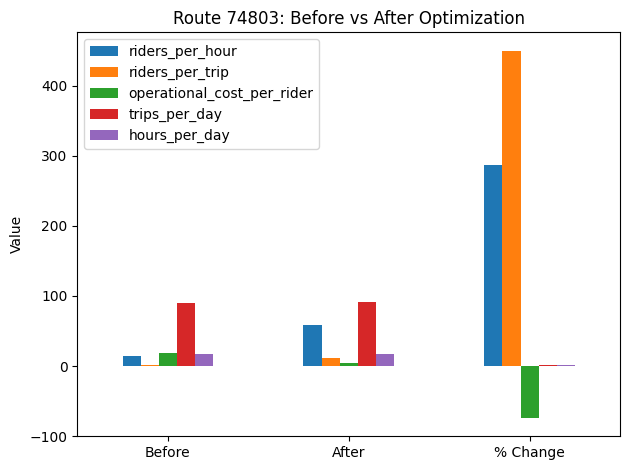


=== BEFORE VS AFTER COMPARISON FOR ROUTE 74968 ===
                riders_per_day riders_per_hour riders_per_trip  \
Before                     656              11               5   
After                     2950              51              26   
% Change            349.695122      363.636364           420.0   
Target Achieved            Yes             Yes             Yes   

                operational_cost_per_rider operational_cost_per_day  \
Before                            23.47561                  15400.0   
After                             5.323541                  15708.0   
% Change                          -77.3231                      2.0   
Target Achieved                        Yes                Optimized   

                trips_per_day hours_per_day  
Before                    110          56.0  
After                     113         57.12  
% Change             2.727273           2.0  
Target Achieved     Optimized     Optimized  


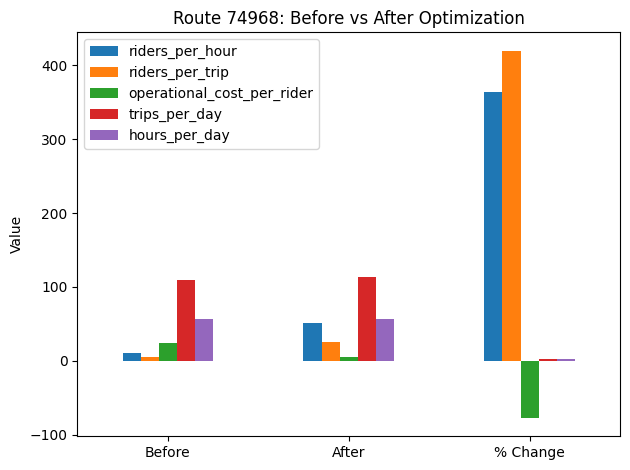


=== BEFORE VS AFTER COMPARISON FOR ROUTE 74796 ===
                riders_per_day riders_per_hour riders_per_trip  \
Before                     909              17              13   
After                     2118              40              31   
% Change              133.0033      135.294118      138.461538   
Target Achieved            Yes             Yes             Yes   

                operational_cost_per_rider operational_cost_per_day  \
Before                           15.429043                  14025.0   
After                              6.75211                  14305.5   
% Change                        -56.237662                      2.0   
Target Achieved                        Yes                Optimized   

                trips_per_day hours_per_day  
Before                     66          51.0  
After                      67         52.02  
% Change             1.515152           2.0  
Target Achieved     Optimized     Optimized  


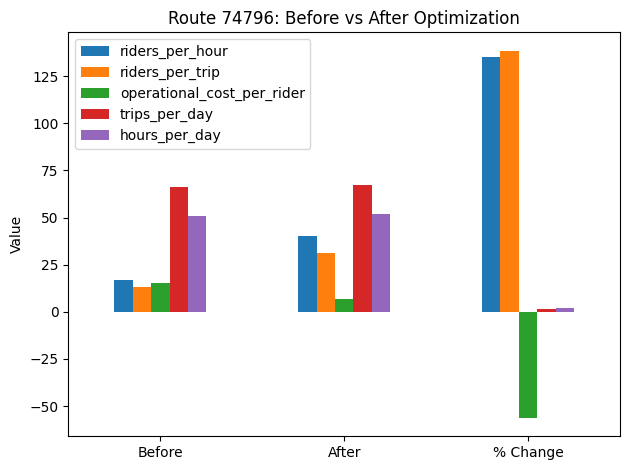


=== BEFORE VS AFTER COMPARISON FOR ROUTE 74821 ===
                riders_per_day riders_per_hour riders_per_trip  \
Before                    2706              22              27   
After                     4160              45              41   
% Change             53.732446      104.545455       51.851852   
Target Achieved            Yes             Yes             Yes   

                operational_cost_per_rider operational_cost_per_day  \
Before                           12.398374                  33550.0   
After                             5.986604             24905.995675   
% Change                        -51.714603               -25.764543   
Target Achieved                        Yes                Optimized   

                trips_per_day hours_per_day  
Before                     98         122.0  
After                     100     90.567257  
% Change             2.040816    -25.764543  
Target Achieved     Optimized     Optimized  


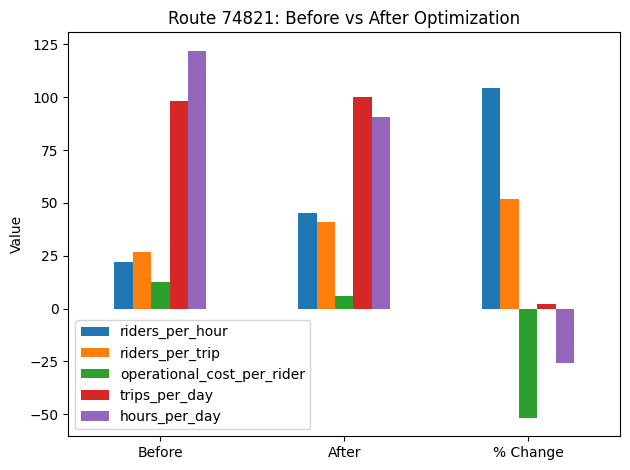


=== BEFORE VS AFTER COMPARISON FOR ROUTE 74833 ===
                riders_per_day riders_per_hour riders_per_trip  \
Before                    1839              24              25   
After                     3240              42              43   
% Change             76.182708            75.0            72.0   
Target Achieved            Yes             Yes             Yes   

                operational_cost_per_rider operational_cost_per_day  \
Before                           11.215334                  20625.0   
After                             6.492327                  21037.5   
% Change                        -42.112053                      2.0   
Target Achieved                        Yes                Optimized   

                trips_per_day hours_per_day  
Before                     73          75.0  
After                      75          76.5  
% Change             2.739726           2.0  
Target Achieved     Optimized     Optimized  


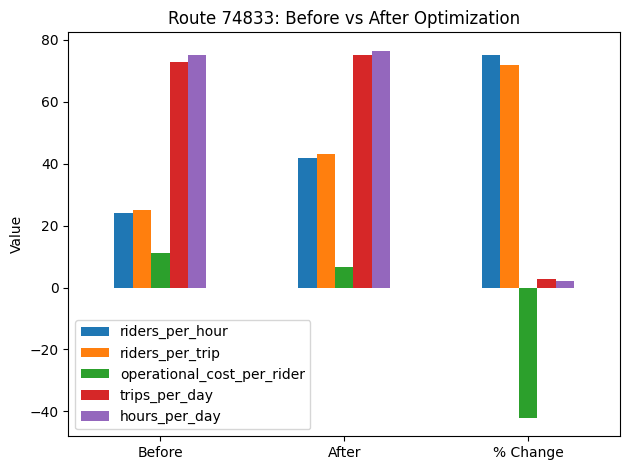

In [33]:
    # ----- Phase 6: Scenario Testing (Before vs After) -----
    for route in before_per_day['route_id'].unique():
        before_row = before_per_day.loc[before_per_day['route_id'] == route].reset_index(drop=True)
        after_row = after_per_day.loc[after_per_day['route_id'] == route].reset_index(drop=True)

        # Rename columns for 'after' row
        after_row = after_row.rename(columns={
            'expected_riders_per_day': 'riders_per_day',
            'opt_riders_per_hour': 'riders_per_hour',
            'opt_riders_per_trip': 'riders_per_trip',
            'opt_operational_cost_per_day': 'operational_cost_per_day',
            'opt_operational_cost_per_rider': 'operational_cost_per_rider',
            'opt_trips_per_day': 'trips_per_day',
            'opt_hours_per_day': 'hours_per_day',
        })

                # Combine them for comparison
        comparison = pd.concat([before_row, after_row], ignore_index=True)
        comparison.index = ['Before', 'After']

        # Compute percentage change ((After - Before) / Before) * 100
        percent_change = ((comparison.loc['After'] - comparison.loc['Before']) / comparison.loc['Before']) * 100
        percent_change = percent_change.to_frame().T
        percent_change.index = ['% Change']

        # Preparing columns for Target Achieved row
        optm_cols = ['trips_per_day', 'hours_per_day','operational_cost_per_day']
        cost_col = ['operational_cost_per_rider']

        # Function to compute Target Achieved status
        def achieve_status(col_name, pct_value):
            # "Optimized" for trips & hours
            if col_name in optm_cols:
                return "Optimized"
            
            # Cost decreases by 7% or more - Achieved
            if col_name in cost_col:
                return "Yes" if pct_value <= -7 else "No"
            
            # route_id column, return N/A
            if col_name == 'route_id':
                return "N/A"
            
            # Default: increase of 7% or more - Achieved
            return "Yes" if pct_value >= 7 else "No"

        # Build Target Achieved row
        target_achieved = percent_change.apply(
            lambda col: achieve_status(col.name, col.iloc[0])
        )
        target_achieved = target_achieved.to_frame().T
        target_achieved.index = ["Target Achieved"]

        # Append rows
        comparison = pd.concat([comparison, percent_change, target_achieved], axis=0)

        print(f"\n=== BEFORE VS AFTER COMPARISON FOR ROUTE {route} ===")
        print(comparison[['riders_per_day', 'riders_per_hour', 'riders_per_trip',
                        'operational_cost_per_rider','operational_cost_per_day',
                        'trips_per_day','hours_per_day']])
        
        # Ensure results directory exists
        output_dir = "results"
        os.makedirs(output_dir, exist_ok=True)

        # Ensure results directory exists under the Optimize&ScenarioTest folder (same folder as this script)
        script_dir = os.getcwd()
        output_dir = os.path.join(script_dir, "results")
        os.makedirs(output_dir, exist_ok=True)


        # Select only numeric rows for plotting
        numeric_rows = ['Before', 'After', '% Change']

        comparison_numeric = comparison.loc[numeric_rows]

        # Visualization
        comparison_numeric[['riders_per_hour', 'riders_per_trip','operational_cost_per_rider',
                    'trips_per_day','hours_per_day']].plot.bar(title=f'Route {route}: Before vs After Optimization', rot=0
        )
        plt.ylabel('Value')
        plt.tight_layout()

        # Save figure as PNG
        output_path = os.path.join(output_dir, f"comparison_plot_route_{route}.png")
        plt.savefig(output_path, dpi=300)
        plt.show()
        plt.close() 

        # Save comparison table as CSV
        comparison.to_csv(os.path.join(output_dir, f"comparison_table_route_{route}.csv"), index=True)